<a href="https://colab.research.google.com/github/Uwais-ur-Rehman/ML-Project/blob/main/K_NN_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Placement.csv')
df.sample(2)

,Student_ID,CGPA,IQ,Placement
50,51,3.5,233,0
12,13,5.4,139,0


In [ ]:
df.isnull().sum()

,0
Student_ID,0
CGPA,0
IQ,0
Placement,0


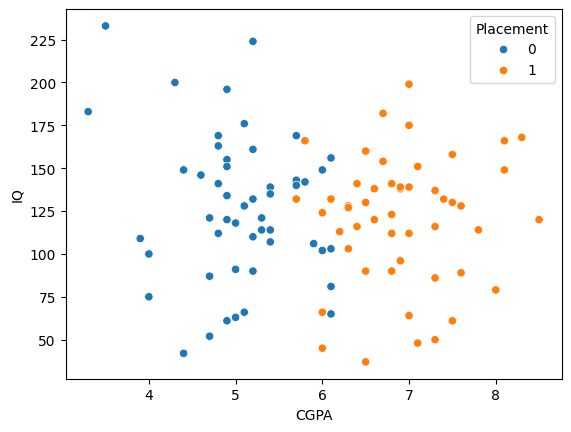

In [ ]:
sns.scatterplot(x='CGPA',y='IQ',hue='Placement',data=df)
plt.show()

In [ ]:
x=df.drop(columns=['Student_ID','Placement'])
y=df['Placement']

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=pd.DataFrame(sc.fit_transform(x))

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
x_train

,0,1
2,-0.607258,-0.064915
73,-0.958783,-1.574578
97,0.623077,1.469908
62,0.007909,-0.542975
19,-0.695139,0.211856
...,...,...
75,-1.046664,1.142815
9,-0.783021,-1.448773
72,1.150364,-0.190721
12,-0.519377,0.387983


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=6)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=6)

In [ ]:
knn.score(x_test,y_test)*100

90.0

In [ ]:
knn.score(x_train,y_train)*100

93.75

In [ ]:
for i in range(1,30):
  knn1=KNeighborsClassifier(n_neighbors=i)
  knn1.fit(x_train,y_train)
  print(i,knn1.score(x_train,y_train)*100,knn1.score(x_test,y_test)*100,knn1.score(x_train,y_train)*100-knn1.score(x_test,y_test)*100)

1 100.0 85.0 15.0
2 96.25 85.0 11.25
3 95.0 90.0 5.0
4 96.25 90.0 6.25
5 96.25 90.0 6.25
6 93.75 90.0 3.75
7 92.5 85.0 7.5
8 92.5 85.0 7.5
9 92.5 85.0 7.5
10 92.5 80.0 12.5
11 91.25 85.0 6.25
12 92.5 85.0 7.5
13 90.0 80.0 10.0
14 90.0 85.0 5.0
15 90.0 80.0 10.0
16 91.25 85.0 6.25
17 90.0 80.0 10.0
18 91.25 80.0 11.25
19 91.25 80.0 11.25
20 91.25 80.0 11.25
21 91.25 80.0 11.25
22 91.25 85.0 6.25
23 91.25 85.0 6.25
24 92.5 85.0 7.5
25 93.75 80.0 13.75
26 92.5 80.0 12.5
27 92.5 80.0 12.5
28 93.75 80.0 13.75
29 93.75 85.0 8.75


In [ ]:
knn.predict([[-0.167853,0.463466]])

array([0])

In [ ]:
x,y

(           0         1
 0   0.710958 -0.014593
 1  -0.079972 -0.442331
 2  -0.607258 -0.064915
 3   1.238245  0.211856
 4  -0.167853  0.463466
 ..       ...       ...
 95 -1.486069  1.922807
 96 -1.398188 -2.052638
 97  0.623077  1.469908
 98  0.271553 -0.517814
 99  0.183671 -0.266204
 
 [100 rows x 2 columns],
 0     1
 1     0
 2     0
 3     1
 4     0
      ..
 95    0
 96    0
 97    1
 98    1
 99    1
 Name: Placement, Length: 100, dtype: int64)

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score,recall_score,precision_score
y_pred=knn.predict(x_test)
print(confusion_matrix(y_test,y_pred))

[[11  1]
 [ 1  7]]


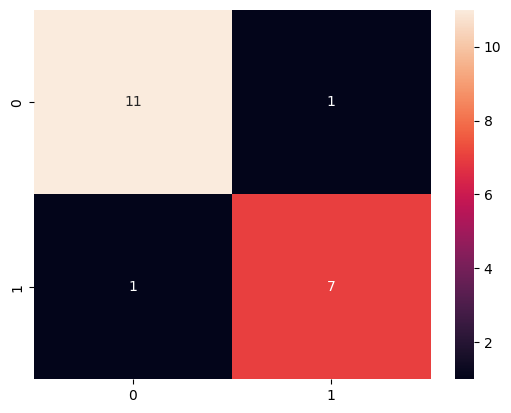

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)
plt.show()

In [ ]:
print("f1_score",f1_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))

f1_score 0.875
accuracy_score 0.9
recall_score 0.875
precision_score 0.875


In [ ]:
df.shape

(100, 4)

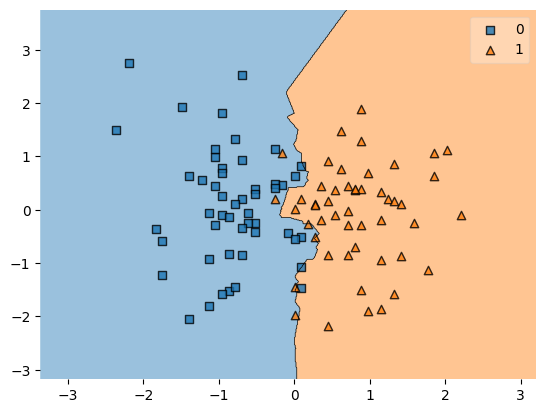

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.values,y.values,clf=knn)
plt.show()

In [ ]:
x_train

,0,1
2,-0.607258,-0.064915
73,-0.958783,-1.574578
97,0.623077,1.469908
62,0.007909,-0.542975
19,-0.695139,0.211856
...,...,...
75,-1.046664,1.142815
9,-0.783021,-1.448773
72,1.150364,-0.190721
12,-0.519377,0.387983
